<a href="https://colab.research.google.com/github/ThandoZwane06/Cisco-Data-Science-Essentials/blob/main/Cisco-Data-Science-Essentials/Lessons/Week_2_Lessons/Sa_Fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#upload file
from google.colab import files
uploaded = files.upload()

Saving sa_fraud_transactions.csv to sa_fraud_transactions.csv


In [3]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#read csv file
sa_fraud = pd.read_csv('sa_fraud_transactions.csv')
sa_fraud.head()

,transaction_id,customer_id,timestamp,amount_zar,merchant_category,province,customer_home_province,is_fraud
0,TXN00001,CUST031,2026-01-01 02:24:15,1881.28,Clothing,Gauteng,Gauteng,1
1,TXN00002,CUST042,2026-01-02 02:50:18,2212.07,Online Retail,North West,North West,1
2,TXN00003,CUST016,2026-01-02 14:05:14,486.45,Fuel,Mpumalanga,Mpumalanga,0
3,TXN00004,CUST017,2026-01-02 16:07:43,2009.66,Travel,Limpopo,Limpopo,0
4,TXN00005,CUST025,2026-01-03 11:04:22,619.25,Clothing,Gauteng,Gauteng,0


In [4]:
#Explore the dataset

#mean spend of each customer
customer_avg = sa_fraud.groupby('customer_id')['amount_zar'].mean().round(2).reset_index()
#change column name to cust_avg_amount
customer_avg = customer_avg.rename(columns={'amount_zar':'cust_avg_amount'})
customer_avg.head()


,customer_id,cust_avg_amount
0,CUST001,518.95
1,CUST002,612.45
2,CUST003,733.13
3,CUST004,551.67
4,CUST005,392.96


In [5]:
#merge customer_avg_amount back to sa_fraud
sa_fraud = sa_fraud.merge(customer_avg, on = 'customer_id', how = 'left')
sa_fraud.head()

,transaction_id,customer_id,timestamp,amount_zar,merchant_category,province,customer_home_province,is_fraud,cust_avg_amount
0,TXN00001,CUST031,2026-01-01 02:24:15,1881.28,Clothing,Gauteng,Gauteng,1,998.13
1,TXN00002,CUST042,2026-01-02 02:50:18,2212.07,Online Retail,North West,North West,1,1065.60
2,TXN00003,CUST016,2026-01-02 14:05:14,486.45,Fuel,Mpumalanga,Mpumalanga,0,568.42
3,TXN00004,CUST017,2026-01-02 16:07:43,2009.66,Travel,Limpopo,Limpopo,0,811.80
4,TXN00005,CUST025,2026-01-03 11:04:22,619.25,Clothing,Gauteng,Gauteng,0,557.51


<BarContainer object of 24 artists>

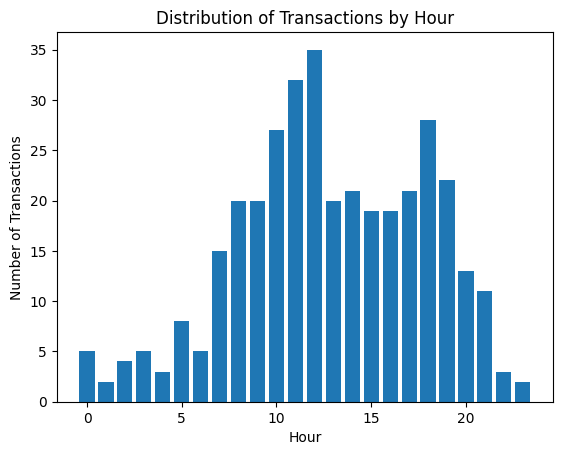

In [6]:
#When are the most transactions made

#convert timestamp to a a datetime format
sa_fraud['timestamp']= pd.to_datetime(sa_fraud['timestamp'])

#extract the hour from the timestamp
sa_fraud['hour'] = sa_fraud['timestamp'].dt.hour

#How many transactions are made every hour
hourly_trans = sa_fraud.groupby('hour')['transaction_id'].count().reset_index()

#plot the distribution
dist_time_plot = plt.bar(hourly_trans['hour'],hourly_trans['transaction_id'])
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Transactions by Hour')
dist_time_plot

In [7]:
#How often does Province differ from the customer's home province?
diff_prov = sa_fraud.query('province != customer_home_province')
diff_prov

,transaction_id,customer_id,timestamp,amount_zar,merchant_category,province,customer_home_province,is_fraud,cust_avg_amount,hour
22,TXN00023,CUST006,2026-01-08 12:32:26,2950.15,Travel,Northern Cape,Gauteng,1,969.92,12
44,TXN00045,CUST016,2026-01-11 13:33:45,704.85,Pharmacy,Limpopo,Mpumalanga,1,568.42,13
120,TXN00121,CUST019,2026-01-29 21:30:09,1287.06,Clothing,North West,Northern Cape,1,791.39,21
213,TXN00214,CUST011,2026-02-26 07:13:45,1730.80,Clothing,Northern Cape,Western Cape,1,1701.94,7
276,TXN00277,CUST005,2026-03-12 19:12:36,134.16,Pharmacy,KwaZulu-Natal,Mpumalanga,1,392.96,19
277,TXN00278,CUST039,2026-03-12 19:48:34,919.31,Clothing,Eastern Cape,Mpumalanga,1,839.95,19


In [8]:
# checking for multiple transactions happening within a short time span

# 1. Sort data by customer id and time
sa_fraud = sa_fraud.sort_values(by=["customer_id", "timestamp"])

# 2. Calculate the time difference between customer's consecutive transactions (in minutes)
sa_fraud["time_diff_between_trans"] = (sa_fraud.groupby("customer_id")["timestamp"].diff().dt.total_seconds().round(1))
sa_fraud["time_diff_between_trans"] = (sa_fraud["time_diff_between_trans"] / 60.0).round(0)

# 3. Display the shortest gaps safely
sa_fraud.sort_values(by="time_diff_between_trans").dropna(subset=["time_diff_between_trans"]).head(20)


,transaction_id,customer_id,timestamp,amount_zar,merchant_category,province,customer_home_province,is_fraud,cust_avg_amount,hour,time_diff_between_trans
178,TXN00179,CUST038,2026-02-14 16:35:03,839.67,Electronics,Western Cape,Western Cape,1,1027.77,16,1.0
346,TXN00347,CUST037,2026-03-28 18:47:01,736.74,Groceries,Western Cape,Western Cape,1,715.60,18,1.0
334,TXN00335,CUST025,2026-03-26 19:11:41,121.73,Entertainment,Gauteng,Gauteng,1,557.51,19,3.0
82,TXN00083,CUST015,2026-01-20 11:06:56,399.41,Restaurants,Limpopo,Limpopo,1,526.31,11,7.0
118,TXN00119,CUST034,2026-01-29 18:55:01,736.71,Fuel,Mpumalanga,Mpumalanga,1,600.14,18,7.0
119,TXN00120,CUST034,2026-01-29 19:02:01,736.71,Fuel,Mpumalanga,Mpumalanga,1,600.14,19,7.0
347,TXN00348,CUST037,2026-03-28 18:54:01,736.74,Groceries,Western Cape,Western Cape,1,715.60,18,7.0
74,TXN00075,CUST019,2026-01-18 17:53:41,173.59,Entertainment,Northern Cape,Northern Cape,1,791.39,17,7.0
75,TXN00076,CUST019,2026-01-18 18:02:41,173.59,Entertainment,Northern Cape,Northern Cape,1,791.39,18,9.0
345,TXN00346,CUST037,2026-03-28 18:46:01,736.74,Groceries,Western Cape,Western Cape,1,715.60,18,10.0


# Suspicion Rules

**Rule 1: Late-Night Spending Spikes**
* Flag any transaction occurring between **1:00 AM and 5:00 AM** where the amount is **2 times larger** than that specific customer's historical average.
* This rule targets sudden, aggressive account draining. A low-value late-night transaction could just be an automated subscription renewal or an emergency purchase but a spike to 3x a customer's typical average during dead hours is a serious mathematical anomaly, not a coincidence.

**Rule 2: Out-of-Province Restrictions**
* Flag any transaction where the merchant's province doesn't match the customer's home province (`province != customer_home_province`).
* Cross-province spending is structurally normal for the `Travel` category (flights, hotels, car rentals), so `Travel` is excluded to avoid false alarms. Local categories like `Pharmacy` or `Clothing` stay flagged if swiped out-of-province, since there's no legitimate reason for that pattern.

**Rule 3: Rapid Consecutive Transactions**
* Flag any transaction occurring within **15 minutes or less** of a previous transaction by the same customer (`0 < time_diff_between_trans <= 15`).
* Legitimate shopping habits are usually spaced out by hours, not minutes. A tight 15-minute window acts as a net for card-cloning streaks, where a fraudster fires off rapid, back-to-back purchases before the account holder notices or the bank locks the card.

**Rule 4: Amount Anomaly (Any Time)**
* Flag any transaction where the amount is **3 times larger** than that specific customer's historical average, regardless of the hour it occurs (`amount_zar > 3 * cust_avg_amount`).
* This rule was added after evaluating Rule 1 in isolation. Rule 1 only flags amount spikes that occur between 1:00 AM and 5:00 AM, but nearly half of the fraud cases missed during evaluation were amount anomalies happening at completely normal hours — a customer with a typical spend of R1,700 suddenly transacting R6,200 at 1:00 PM, for example. Requiring both "late-night" and "large amount" in a single condition was too strict, since the two signals don't always co-occur. Rule 4 isolates the amount signal on its own, independent of time of day, to close that gap.


In [19]:
#Define rules to code

#Rule1
rule1_night_spikes = "1 <= hour <= 5 and amount_zar > (2 * cust_avg_amount)"

#Rule2
rule2_loc = "province != customer_home_province and merchant_category != 'Travel'"

#Rule3
rule3_consec = "0 < time_diff_between_trans <= 15"

#Rule4
rule4_amount = "amount_zar > (3 * cust_avg_amount)"


In [20]:
#define is_suspicious as safe
sa_fraud['is_suspicious'] = 0

#combine the rules
combined_rule = f"({rule1_night_spikes}) or ({rule2_loc}) or ({rule3_consec}) or ({rule4_amount})"

#which rows break our defined rules
flagged_rows = sa_fraud.query(combined_rule)

#flagged rows should be changed from 0 to 1
sa_fraud.loc[flagged_rows.index, 'is_suspicious'] = 1

#check the distribution of flagged transactions
print("Fraud Results (0 = Safe, 1 = Flagged):")
print(sa_fraud['is_suspicious'].value_counts())


Fraud Results (0 = Safe, 1 = Flagged):
is_suspicious
0    334
1     26
Name: count, dtype: int64


In [21]:

pd.crosstab(sa_fraud['is_suspicious'], sa_fraud['is_fraud'], rownames=['Predicted'], colnames=['Actual'])

Actual,0,1
Predicted,,
0,320,14
1,4,22
